In [4]:
import pickle
import sys
import time 
import zipfile
import numpy as np

def tic():
  return time.time()

def toc(tstart, nm=""):
  print('%s took: %s sec.\n' % (nm,(time.time() - tstart)))

def read_data(fname):
  d = []
  with open(fname, 'rb') as f:
    if sys.version_info[0] < 3:
      d = pickle.load(f)
    else:
      d = pickle.load(f, encoding='latin1')  # need for python 3
  return d

dataset="1"
cfile = "trainset/cam/cam" + dataset + ".p"
ifile = "trainset/imu/imuRaw" + dataset + ".p"
vfile = "trainset/vicon/viconRot" + dataset + ".p"

ts = tic()
camd = read_data(cfile)
imud = read_data(ifile)
vicd = read_data(vfile)
toc(ts,"Data import")


print(type(imud))
print(type(vicd))
print(type(camd))


Data import took: 4.287523031234741 sec.

<class 'numpy.ndarray'>
<class 'dict'>
<class 'dict'>


In [5]:
print("imu shape:", imud.shape)
print("vicd shape:", vicd.keys())
print("camd shape:", camd.keys())

imu shape: (7, 5645)
vicd shape: dict_keys(['rots', 'ts'])
camd shape: dict_keys(['cam', 'ts'])


In [6]:
print(type(vicd['rots']))
print(type(camd['cam']))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [7]:
print('vicd_rots:', np.shape(vicd['rots']))
print('vicd_ts:', np.shape(vicd['ts']))
print('camd_cam:', np.shape(camd['cam']))
print('camd_ts:', np.shape(camd['ts']))
print('imu_tau_t:', np.diff(imud[0,:10]))
print('vicd_tau_t:', np.diff(vicd['ts'][0,:10]))
print('camd_tau_t:', np.diff(camd['ts'][0,:10]))


vicd_rots: (3, 3, 5561)
vicd_ts: (1, 5561)
camd_cam: (240, 320, 3, 1685)
camd_ts: (1, 1685)
imu_tau_t: [0.00981092 0.01030397 0.00956511 0.01058006 0.00952196 0.01057792
 0.00952005 0.01060104 0.00952888]
vicd_tau_t: [0.01294303 0.01185203 0.00937295 0.01202512 0.00844383 0.01024699
 0.01732516 0.0099709  0.00268292]
camd_tau_t: [0.0317049  0.03550315 0.03228283 0.03230309 0.03553391 0.03235412
 0.03238201 0.03549194 0.03214407]


In [8]:
#imu calibration
sf_acc = 3300 / 1023 / 330
sf_w = (3300 / 1023 / 3.33) * np.pi / 180
SF = np.array([
    [sf_acc],
    [sf_acc],
    [sf_acc],
    [sf_w],
    [sf_w],
    [sf_w]
])


BIAS = np.mean(imud[1:7, :700], axis=1, keepdims=True)
BIAS[2, 0] -= (1 / sf_acc)
calibrated_imud = (imud[1:7, :] - BIAS) * SF
calibrated_imud[0, :] = calibrated_imud[0, :]   
calibrated_imud[1, :] = calibrated_imud[1, :] 
print(np.shape(calibrated_imud))

(6, 5645)


In [9]:
final_imud = np.concatenate((imud[0:1, :], calibrated_imud), axis=0)
print(np.shape(final_imud))
final_imud[:7,:10]

(7, 5645)


array([[ 1.29663678e+09,  1.29663678e+09,  1.29663678e+09,
         1.29663678e+09,  1.29663678e+09,  1.29663678e+09,
         1.29663678e+09,  1.29663678e+09,  1.29663678e+09,
         1.29663678e+09],
       [-1.88521156e-03, -1.88521156e-03, -1.88521156e-03,
        -1.88521156e-03,  7.88995950e-03, -1.88521156e-03,
        -1.88521156e-03, -1.88521156e-03, -1.88521156e-03,
        -1.88521156e-03],
       [-5.58581204e-05, -5.58581204e-05, -5.58581204e-05,
        -5.58581204e-05, -5.58581204e-05, -5.58581204e-05,
        -5.58581204e-05, -5.58581204e-05, -5.58581204e-05,
        -5.58581204e-05],
       [ 9.98449937e-01,  9.98449937e-01,  1.00822511e+00,
         9.98449937e-01,  9.98449937e-01,  9.98449937e-01,
         9.98449937e-01,  9.98449937e-01,  9.98449937e-01,
         9.98449937e-01],
       [ 7.24593869e-03, -9.66125159e-03,  7.24593869e-03,
         7.24593869e-03,  7.24593869e-03, -9.66125159e-03,
         7.24593869e-03,  7.24593869e-03, -2.65684419e-02,
         7.

In [10]:
#Orientation estimation: optimized with projected gradient descent
import jax
import jax.numpy as jnp
import numpy as np
import time
import pickle


def q_mult(q1, q2):
    w1,x1,y1,z1 = q1[...,0], q1[...,1], q1[...,2], q1[...,3]
    w2,x2,y2,z2 = q2[...,0], q2[...,1], q2[...,2], q2[...,3]
    w = w1*w2 - x1*x2 - y1*y2 - z1*z2
    x = w1*x2 + x1*w2 + y1*z2 - z1*y2
    y = w1*y2 - x1*z2 + y1*w2 + z1*x2
    z = w1*z2 + x1*y2 - y1*x2 + z1*w2
    return jnp.stack([w,x,y,z], axis=-1)

def qinverse(q):
    return jnp.stack([q[...,0], -q[...,1], -q[...,2], -q[...,3]], axis=-1)

def axangle2quat_jax(axis, theta):
    half = theta/2
    w = jnp.cos(half)
    xyz = axis * jnp.sin(half)[..., None]
    return jnp.concatenate([w[..., None], xyz], axis=-1)

def quat_log_vec_jax(q, eps=1e-8):
    w = q[..., 0]
    xyz = q[..., 1:]
    norm_xyz = safe_norm(xyz)
    theta = 2*jnp.arctan2(norm_xyz, w)
    axis = xyz / (norm_xyz[..., None] + eps)
    return axis * theta[..., None]

def obj_model(q_t):
    q_g = jnp.broadcast_to(jnp.array([0.,0.,0.,1.]), q_t.shape)
    q1 = q_mult(qinverse(q_t), q_g)
    h_qt = q_mult(q1, q_t)
    return h_qt[..., 1:]

def motion_model(q_t, w_t, tau_t):
    v = w_t * tau_t[..., None]
    theta = safe_norm(v)
    theta_safe = jnp.where(theta < 1e-8, 1.0, theta)
    axis = v / theta_safe[..., None]
    dp = axangle2quat_jax(axis, theta)
    identity = jnp.zeros_like(dp).at[..., 0].set(1.0)
    dp = jnp.where((theta < 1e-8)[..., None], identity, dp)
    q_next = q_mult(q_t, dp)
    return q_next / jnp.linalg.norm(q_next, axis=-1, keepdims=True)

def safe_norm(x, axis=-1, eps=1e-8):
    return jnp.sqrt(jnp.sum(x**2, axis=axis) + eps**2)


@jax.jit
def cost_function(q_traj, imu):
    T = q_traj.shape[0]
    q_t = q_traj[:-1]
    q_next = q_traj[1:]
    tau_t = imu[0, 1:] - imu[0, :-1]
    w_t = imu[[5,6,4], :-1].T
    a_t = imu[1:4, :-1].T

    f = motion_model(q_t, w_t, tau_t)
    q_err = q_mult(qinverse(q_next), f)
    axis_angle_err = quat_log_vec_jax(q_err)
    motion_loss = jnp.sum(axis_angle_err**2)

    h = obj_model(q_t)
    obs_loss = jnp.sum((a_t - h)**2)

    total_cost = 0.5*motion_loss + 0.5*obs_loss
    return total_cost/T

grad_cost_fn = jax.jit(jax.grad(cost_function, argnums=0))


@jax.jit
def project_step(q_traj, grad_q, lr):
    dot_prod = jnp.sum(grad_q * q_traj, axis=-1, keepdims=True)
    h_k = grad_q - dot_prod * q_traj
    h_norm = jnp.linalg.norm(h_k, axis=-1, keepdims=True)
    safe_norm = jnp.where(h_norm > 1e-10, h_norm, 1.0)
    n_k = h_k / safe_norm
    phi_k = lr * h_norm
    new_q = q_traj * jnp.cos(phi_k) - n_k * jnp.sin(phi_k)
    q_traj_updated = jnp.where(h_norm > 1e-10, new_q, q_traj)
    return q_traj_updated, phi_k


lr = 100
decay_every = 90
decay_rate = 0.25
n = 200
T = final_imud.shape[1]
q_traj = jnp.array(np.zeros((T,4)).astype(np.float32))
q_traj = q_traj.at[:,0].set(1.0)
final_imud = jnp.array(final_imud, dtype=jnp.float32)

cost_history = []
save_every = 10

best_cost = float('inf')     
best_q_traj = np.array(q_traj)  

for i in range(n):
    if i > 0 and i % decay_every == 0:
        lr = lr * decay_rate
    grad_q = grad_cost_fn(q_traj, final_imud)
    q_traj, phi_k = project_step(q_traj, grad_q, lr)

    if i % save_every == 0:
        c_val = float(cost_function(q_traj, final_imud))
        cost_history.append((i, c_val))
        print(f"Iteration {i}, Cost: {c_val:.6f}, phi max: {float(jnp.max(phi_k)):.6f}, lr: {lr:.4f}")

        if c_val < best_cost:
            best_cost = c_val
            best_q_traj = np.array(q_traj)

print(f"best cost: {best_cost}")

with open("q_traj_final.pkl", "wb") as f:
    pickle.dump({
        "q_traj": best_q_traj,          
        "cost_history": cost_history,
        "final_cost": best_cost         
    }, f)



Iteration 0, Cost: 0.201794, phi max: 0.037933, lr: 100.0000
Iteration 10, Cost: 0.066277, phi max: 0.030130, lr: 100.0000
Iteration 20, Cost: 0.017232, phi max: 0.016770, lr: 100.0000
Iteration 30, Cost: 0.004570, phi max: 0.008147, lr: 100.0000
Iteration 40, Cost: 0.001635, phi max: 0.003853, lr: 100.0000
Iteration 50, Cost: 0.000973, phi max: 0.001849, lr: 100.0000
Iteration 60, Cost: 0.000824, phi max: 0.000888, lr: 100.0000
Iteration 70, Cost: 0.000790, phi max: 0.000427, lr: 100.0000
Iteration 80, Cost: 0.000783, phi max: 0.000206, lr: 100.0000
Iteration 90, Cost: 0.000781, phi max: 0.000025, lr: 25.0000
Iteration 100, Cost: 0.000781, phi max: 0.000021, lr: 25.0000
Iteration 110, Cost: 0.000781, phi max: 0.000018, lr: 25.0000
Iteration 120, Cost: 0.000781, phi max: 0.000016, lr: 25.0000
Iteration 130, Cost: 0.000781, phi max: 0.000014, lr: 25.0000
Iteration 140, Cost: 0.000781, phi max: 0.000012, lr: 25.0000
Iteration 150, Cost: 0.000781, phi max: 0.000011, lr: 25.0000
Iteration 

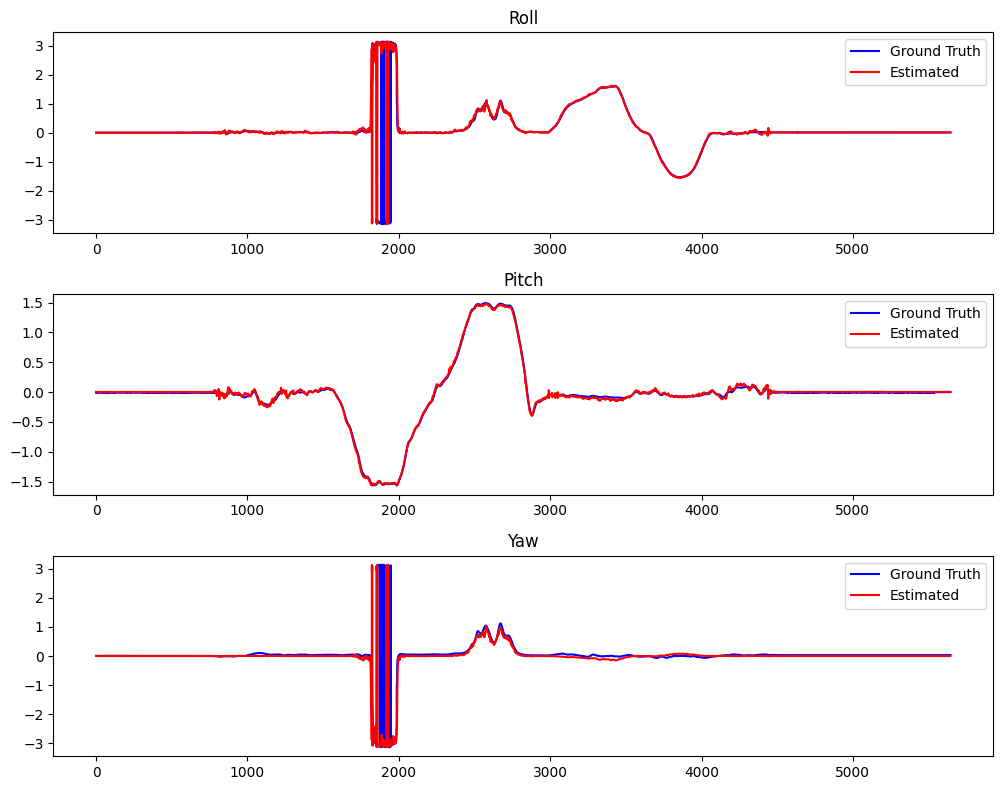

In [11]:
import numpy as np
import transforms3d.euler as te
import matplotlib.pyplot as plt


T_result = best_q_traj.shape[0]
euler_est = np.zeros((T_result, 3))
for t in range(T_result):
    q = np.asarray(best_q_traj[t], dtype=np.float64)
    euler_est[t] = te.quat2euler(q, axes='sxyz')
roll_est, pitch_est, yaw_est = euler_est[:, 0], euler_est[:, 1], euler_est[:, 2]


imu_ts = np.array(imud[0, :], dtype=np.float64)
vicon_ts = vicd['ts'].flatten().astype(np.float64)

roll_gt = np.zeros(T_result)
pitch_gt = np.zeros(T_result)
yaw_gt = np.zeros(T_result)
for t in range(T_result):
    idx = np.argmin(np.abs(vicon_ts - imu_ts[t]))
    R_gt = vicd['rots'][:, :, idx]
    roll_gt[t], pitch_gt[t], yaw_gt[t] = te.mat2euler(R_gt, axes='sxyz')


fig, axes = plt.subplots(3, 1, figsize=(10, 8))
axes[0].plot(roll_gt, 'b-', label='Ground Truth')
axes[0].plot(roll_est, 'r-', label='Estimated')
axes[0].set_title('Roll'); axes[0].legend()
axes[1].plot(pitch_gt, 'b-', label='Ground Truth')
axes[1].plot(pitch_est, 'r-', label='Estimated')
axes[1].set_title('Pitch'); axes[1].legend()
axes[2].plot(yaw_gt, 'b-', label='Ground Truth')
axes[2].plot(yaw_est, 'r-', label='Estimated')
axes[2].set_title('Yaw'); axes[2].legend()
plt.tight_layout()
plt.savefig('orientation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.show()

In [17]:
# Quantitative accuracy: RMSE between estimated and ground-truth angles (in degrees)
def wrap_deg(diff_rad):
    diff_deg = np.rad2deg(diff_rad)
    return (diff_deg + 180) % 360 - 180

def rmse_deg_wrapped(est, gt):
    diff = wrap_deg(est - gt)
    return np.sqrt(np.mean(diff ** 2))

roll_rmse = rmse_deg_wrapped(roll_est, roll_gt)
pitch_rmse = rmse_deg_wrapped(pitch_est, pitch_gt)
yaw_rmse = rmse_deg_wrapped(yaw_est, yaw_gt)

print(f"Roll RMSE:  {roll_rmse:.2f} deg")
print(f"Pitch RMSE: {pitch_rmse:.2f} deg")
print(f"Yaw RMSE:   {yaw_rmse:.2f} deg")


Roll RMSE:  5.94 deg
Pitch RMSE: 1.25 deg
Yaw RMSE:   6.61 deg


In [13]:
import transforms3d.quaternions as tq

cam_t=camd['ts'].flatten()
imud_t=imud[0]
idx= np.searchsorted(imud_t, cam_t, side='right') - 1
q_selected=best_q_traj[idx,:]
N=len(cam_t)
R=np.zeros((3,3,N))
for i in range(N):
    R[:,:,i]=tq.quat2mat(q_selected[i])




In [14]:
print(np.shape(R))

(3, 3, 1685)


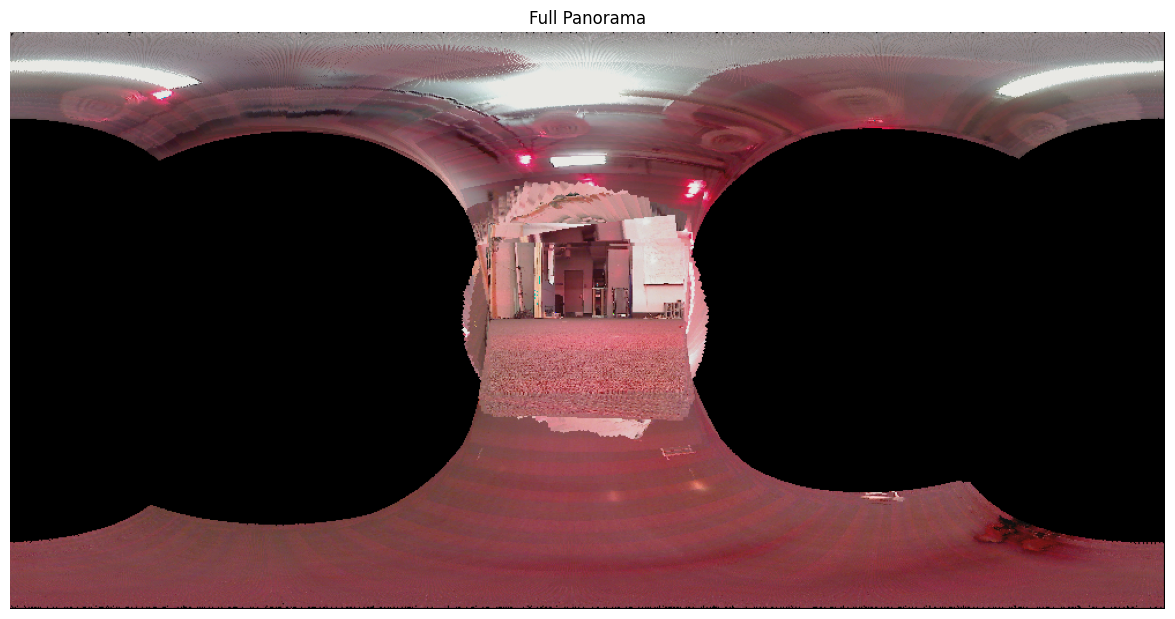

In [15]:
c,r=np.meshgrid(np.arange(320), np.arange(240))
lambda_c=(c-159.5)*60*np.pi/(180*319)
phi_c=(119.5-r)*45*np.pi/(239*180)
x_c=np.cos(phi_c)*np.cos(lambda_c)
y_c=np.cos(phi_c)*np.sin(lambda_c)
z_c=np.sin(phi_c)
p_cam=np.stack([x_c, y_c, z_c], axis=-1)


H_pano=500
W_pano=1000
pano_canvas=np.zeros((H_pano, W_pano, 3), dtype=np.uint8)
N=R.shape[2]
for i in range(N):
    R_k=R[:, :, i]  
    P_W=p_cam @ R_k.T
    current_img=camd['cam'][:, :, :, i]

    X=P_W[:, :, 0]
    Y=P_W[:, :, 1]
    Z=P_W[:, :, 2]

    lambda_w=np.arctan2(Y, X)
    Z_safe=np.clip(Z, -1.0, 1.0)
    phi_w=np.arcsin(Z_safe)


    col_pano=np.floor((lambda_w + np.pi)*(W_pano-1)/(2*np.pi)).astype(int)
    row_pano=np.floor(((np.pi/2)-phi_w)*(H_pano-1)/np.pi).astype(int)

    col_pano=np.clip(col_pano, 0, W_pano-1)
    row_pano=np.clip(row_pano, 0, H_pano-1)

    pano_canvas[row_pano, col_pano]=current_img

plt.figure(figsize=(15, 7.5))
plt.imshow(pano_canvas)
plt.axis('off')
plt.title("Full Panorama")
plt.show()

    


In [16]:
plt.imsave("panorama_result.png", pano_canvas)
